# Extracción de datos Instagram - Lululemon por Hashtags

Se buscan publicaciones (reels y posts) de Instagram relacionados con Lululemon a partir de hashtags.
Se extraen las publicaciones con más engagement y luego se descargan los comentarios de las mejores.

**Dos zonas geográficas** para análisis comparativo (misma lógica que TikTok):
- Estados Unidos → comentarios en inglés
- Europa (ES, FR, GB, DE) → comentarios filtrados por idioma del país

**Filtrado por idioma en comentarios:**
- US → solo inglés
- España → solo español
- Francia → solo francés
- Reino Unido → solo inglés
- Alemania → solo alemán

In [ ]:
from apify_client import ApifyClient
import pandas as pd
import json
from langdetect import detect, LangDetectException

from dotenv import load_dotenv
import os

load_dotenv()
APIFY_TOKEN = os.getenv("APIFY_TOKEN")
client = ApifyClient(APIFY_TOKEN)

In [9]:
# Hashtags relacionados con Lululemon
HASHTAGS = [
    "lululemon",
    "lululemonhaul",
    "lululemonreview",
    "lululemonfavorites",
    "lululemonoutfit",
    "lululemonleggings",
    "lululemontryhaul",
    "lululemonfinds",
]

print(f"Total hashtags: {len(HASHTAGS)}")
for h in HASHTAGS:
    print(f"  #{h}")

Total hashtags: 8
  #lululemon
  #lululemonhaul
  #lululemonreview
  #lululemonfavorites
  #lululemonoutfit
  #lululemonleggings
  #lululemontryhaul
  #lululemonfinds


---
## 1. Funciones auxiliares

In [10]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ast

def parse_hashtags(x):
    """Convierte la columna hashtags a lista."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(t).lower().strip() for t in x]
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                vals = ast.literal_eval(s)
                if isinstance(vals, list):
                    return [str(t).lower().strip() for t in vals]
            except Exception:
                pass
        s = s.replace("#", " ")
        parts = [p.lower().strip() for p in s.split() if p.strip()]
        return parts
    return []

def load_and_standardize(path, kind):
    """Carga CSV de Instagram y estandariza columnas."""
    df = pd.read_csv(path)
    df["kind"] = kind

    col_map_candidates = {
        "url": ["url", "postUrl", "postURL", "link"],
        "timestamp": ["timestamp", "takenAt", "takenAtTimestamp", "createdAt", "date"],
        "likes": ["likesCount", "likeCount", "likes", "likes_count"],
        "comments": ["commentsCount", "commentCount", "comments", "comments_count"],
        "caption": ["caption", "text", "description"],
        "shortCode": ["shortCode", "shortcode", "code"],
        "type": ["type", "productType"]
    }

    def pick_col(cands):
        for c in cands:
            if c in df.columns:
                return c
        return None

    chosen = {k: pick_col(v) for k, v in col_map_candidates.items()}

    df["url_std"] = df[chosen["url"]].astype(str) if chosen["url"] else ""
    df["caption_std"] = df[chosen["caption"]].astype(str) if chosen["caption"] else ""
    df["likes_std"] = pd.to_numeric(df[chosen["likes"]], errors="coerce").fillna(0).astype(int) if chosen["likes"] else 0
    df["comments_std"] = pd.to_numeric(df[chosen["comments"]], errors="coerce").fillna(0).astype(int) if chosen["comments"] else 0

    ts_col = chosen["timestamp"]
    if ts_col:
        if pd.api.types.is_numeric_dtype(df[ts_col]):
            df["timestamp_std"] = pd.to_datetime(df[ts_col], unit="s", errors="coerce")
        else:
            df["timestamp_std"] = pd.to_datetime(df[ts_col], errors="coerce", utc=True).dt.tz_convert(None)
    else:
        df["timestamp_std"] = pd.NaT

    df["year"] = df["timestamp_std"].dt.year
    df["month"] = df["timestamp_std"].dt.to_period("M").astype(str)
    df["score"] = (df["comments_std"] * 3) + (df["likes_std"] * 1)

    if "hashtags" in df.columns:
        df["hashtags_list"] = df["hashtags"].apply(parse_hashtags)
    else:
        df["hashtags"] = np.nan
        df["hashtags_list"] = [[] for _ in range(len(df))]

    extra_cols = [
        "inputUrl", "shortCode", "type", "productType",
        "ownerUsername", "ownerFullName", "ownerId",
        "locationName", "locationId",
        "videoUrl", "videoPlayCount", "igPlayCount", "musicInfo"
    ]
    for c in extra_cols:
        if c not in df.columns:
            df[c] = np.nan

    keep = [
        "kind", "url_std", "shortCode",
        "likes_std", "comments_std", "score",
        "timestamp_std", "year", "month",
        "caption_std", "hashtags", "hashtags_list",
        "inputUrl", "ownerUsername", "ownerFullName", "ownerId",
        "locationName", "locationId",
        "type", "productType",
        "videoUrl", "videoPlayCount", "igPlayCount", "musicInfo"
    ]

    return df[keep].copy()

def safe_detect(text):
    """Detecta idioma de un texto de forma segura."""
    try:
        if pd.isna(text) or str(text).strip() == "":
            return "unknown"
        return detect(str(text))
    except LangDetectException:
        return "unknown"

print("Funciones cargadas.")

Funciones cargadas.


---
## 2. Extracción de reels por hashtag

In [12]:
run_reels = client.actor("apify/instagram-hashtag-scraper").call(run_input={
    "hashtags": HASHTAGS,
    "resultsType": "reels",
    "resultsLimit": 50           # por hashtag
})

items_reels = list(client.dataset(run_reels["defaultDatasetId"]).iterate_items())

with open("../datos/raw/instagram/ig_lululemon_reels.json", "w", encoding="utf-8") as f:
    json.dump(items_reels, f, ensure_ascii=False, indent=2)

pd.DataFrame(items_reels).to_csv("../datos/raw/instagram/ig_lululemon_reels.csv", index=False)

print(f"Reels extraídos: {len(items_reels)}")
print(f"Dataset: {run_reels['defaultDatasetId']}")

[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> Status: RUNNING, Message: 
[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> 2026-03-26T15:16:40.008Z ACTOR: Pulling container image of build 7kO2THRjw5gr9N0aM from registry.
[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> 2026-03-26T15:16:40.010Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> 2026-03-26T15:16:40.074Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> 2026-03-26T15:16:40.075Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> 2026-03-26T15:16:40.645Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.1"}
[apify.instagram-hashtag-scraper runId:w9381mYQhC3ELcJ7H] -> 2026-03-26T15:16:40.908Z INFO  Results Limit [object Object], ACTOR_MAX_PAID_DATASET_ITEMS
[

Reels extraídos: 289
Dataset: VDYjJVuyasbmktPI0


---
## 3. Extracción de posts por hashtag

In [13]:
run_posts = client.actor("apify/instagram-hashtag-scraper").call(run_input={
    "hashtags": HASHTAGS,
    "resultsType": "posts",
    "resultsLimit": 50           # por hashtag
})

items_posts = list(client.dataset(run_posts["defaultDatasetId"]).iterate_items())

with open("../datos/raw/instagram/ig_lululemon_posts.json", "w", encoding="utf-8") as f:
    json.dump(items_posts, f, ensure_ascii=False, indent=2)

pd.DataFrame(items_posts).to_csv("../datos/raw/instagram/ig_lululemon_posts.csv", index=False)

print(f"Posts extraídos: {len(items_posts)}")
print(f"Dataset: {run_posts['defaultDatasetId']}")

[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> Status: RUNNING, Message: 
[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> 2026-03-26T15:17:13.855Z ACTOR: Pulling container image of build 7kO2THRjw5gr9N0aM from registry.
[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> 2026-03-26T15:17:13.857Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> 2026-03-26T15:17:13.896Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> 2026-03-26T15:17:13.897Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> 2026-03-26T15:17:14.532Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.1"}
[apify.instagram-hashtag-scraper runId:6vZ6rSTFYQcdJFbDG] -> 2026-03-26T15:17:14.656Z INFO  Results Limit [object Object], ACTOR_MAX_PAID_DATASET_ITEMS
[

Posts extraídos: 296
Dataset: 3cS4BrENn9dav4zBB


---
## 4. Cargar y analizar resultados

In [14]:
REELS_PATH = "../datos/raw/instagram/ig_lululemon_reels.csv"
POSTS_PATH = "../datos/raw/instagram/ig_lululemon_posts.csv"

reels = load_and_standardize(REELS_PATH, "reel")
posts = load_and_standardize(POSTS_PATH, "post")

df_all = pd.concat([reels, posts], ignore_index=True)

print(f"Reels: {len(reels)}  Posts: {len(posts)}  Total: {len(df_all)}")
df_all.head()

Reels: 289  Posts: 296  Total: 585


,kind,url_std,shortCode,likes_std,comments_std,score,timestamp_std,year,month,caption_std,...,ownerFullName,ownerId,locationName,locationId,type,productType,videoUrl,videoPlayCount,igPlayCount,musicInfo
0,reel,https://www.instagram.com/explore/tags/lululem...,NaN,0,0,0,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,reel,https://www.instagram.com/p/DVvVpoLk390/,DVvVpoLk390,2182,73,2401,2026-03-11 09:49:27,2026.0,2026-03,비싸지만 돈 아깝지 않은 룰루레몬 4가지👌🏻\n\n➰디파인 크롭 재킷\n➰얼라인 레...,...,김다나,1.624129e+09,NaN,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,218623.0,218623.0,"{'artist_name': 'Hearts2Hearts', 'song_name': ..."
2,reel,https://www.instagram.com/p/DWCCAcME6gQ/,DWCCAcME6gQ,1411,44,1543,2026-03-18 16:02:45,2026.0,2026-03,Consider me #Amottivated 🫡\nPhysical 100/Asia ...,...,Karen Santiago,4.038908e+07,NaN,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,44662.0,44662.0,"{'artist_name': 'Usher', 'song_name': ""Hey Dad..."
3,reel,https://www.instagram.com/p/DS3pP7IiTVQ/,DS3pP7IiTVQ,1750,22,1816,2025-12-30 01:44:48,2025.0,2025-12,Signed up for HYROX doubles because apparently...,...,Christina Ratusznik,5.800540e+08,Torque Body Shop,2.279172e+14,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,54788.0,54788.0,"{'artist_name': 'christinaratusznik', 'song_na..."
4,reel,https://www.instagram.com/p/DUZVVB4Dj-P/,DUZVVB4Dj-P,1730,5228,17414,2026-02-06 00:10:49,2026.0,2026-02,comment “TROUSERS” for the ⛓️‍💥🤍\n.\n$148 Lulu...,...,𝚔𝚎𝚗𝚍𝚛𝚊 | 𝚊𝚖𝚊𝚣𝚘𝚗 𝚏𝚊𝚜𝚑𝚒𝚘𝚗 & 𝚘𝚞𝚝𝚏𝚒𝚝 𝚒𝚗𝚜𝚙𝚘,5.165641e+10,NaN,NaN,Video,clips,https://scontent-vie1-1.cdninstagram.com/o1/v/...,127863.0,127863.0,"{'artist_name': 'Archer Marsh', 'song_name': '..."


In [15]:
# Ranking por engagement
df_all = df_all.sort_values("score", ascending=False).reset_index(drop=True)
df_all["rank_global"] = range(1, len(df_all) + 1)
df_all["rank_type"] = df_all.groupby("kind").cumcount() + 1
df_all["label"] = df_all.apply(
    lambda row: f"{row['kind'].capitalize()} {row['rank_type']}", axis=1
)

df_all[["label", "kind", "likes_std", "comments_std", "score", "year", "ownerUsername"]].head(15)

,label,kind,likes_std,comments_std,score,year,ownerUsername
0,Reel 1,reel,131818,1603,136627,2022.0,stephsblessedd
1,Reel 2,reel,61435,123,61804,2025.0,melinatesibeauty
2,Reel 3,reel,32705,119,33062,2025.0,meili_zzz
3,Reel 4,reel,26631,770,28941,2024.0,koreessentials__
4,Reel 5,reel,26330,184,26882,2024.0,hopenichole_
5,Reel 6,reel,25843,331,26836,2026.0,calebkirk__00
6,Reel 7,reel,17561,2800,25961,2025.0,snipestwins
7,Reel 8,reel,22704,148,23148,2024.0,hiladailythrift
8,Reel 9,reel,19754,119,20111,2023.0,stylish.xobrooklynne
9,Reel 10,reel,18936,189,19503,2026.0,aivanelli


---
## 5. Visualizaciones: likes y comentarios

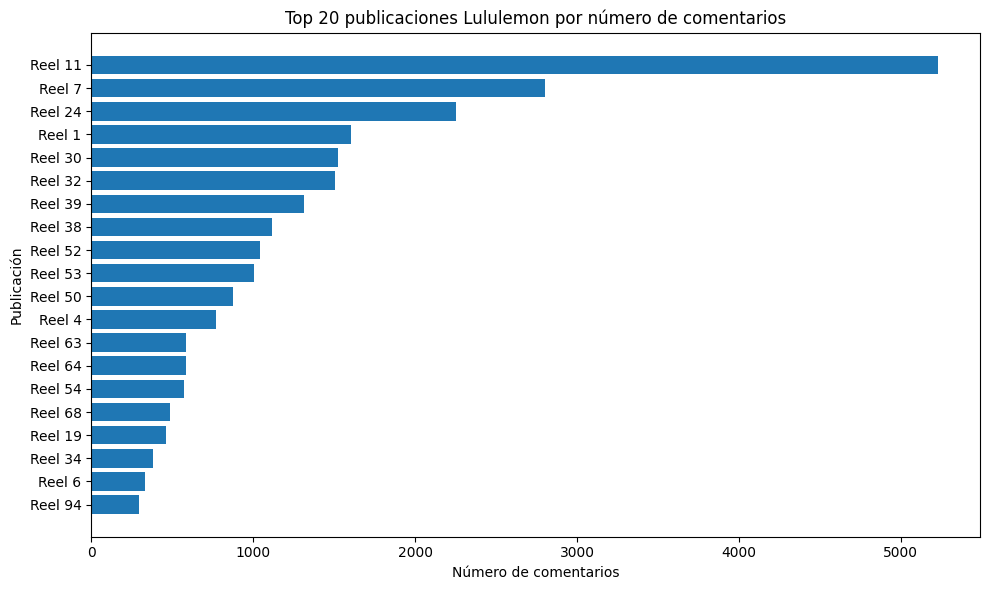

In [16]:
top_comments = df_all.sort_values("comments_std", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_comments["label"], top_comments["comments_std"])
plt.gca().invert_yaxis()
plt.title("Top 20 publicaciones Lululemon por número de comentarios")
plt.xlabel("Número de comentarios")
plt.ylabel("Publicación")
plt.tight_layout()
plt.show()

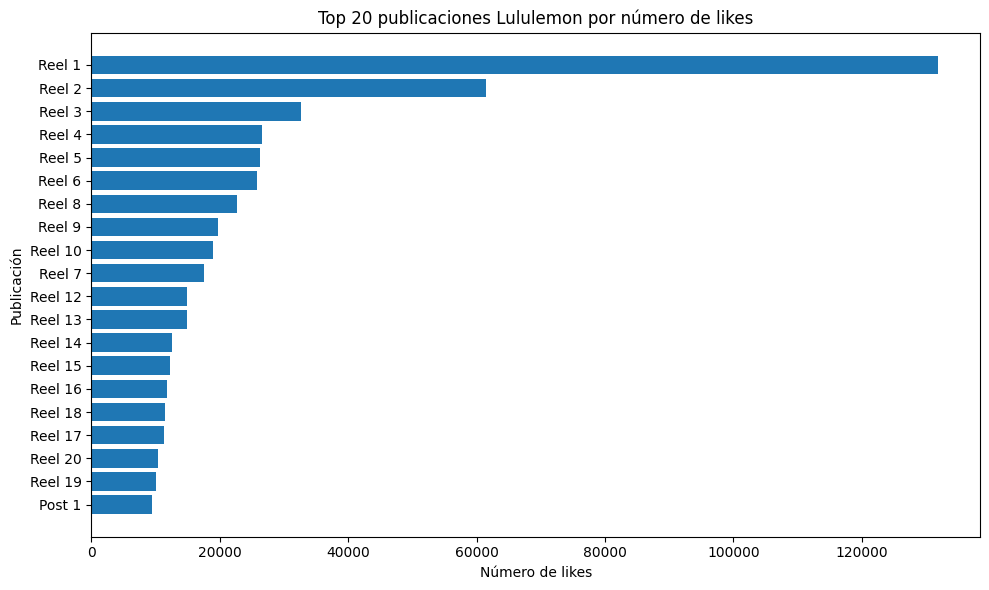

In [17]:
top_likes = df_all.sort_values("likes_std", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_likes["label"], top_likes["likes_std"])
plt.gca().invert_yaxis()
plt.title("Top 20 publicaciones Lululemon por número de likes")
plt.xlabel("Número de likes")
plt.ylabel("Publicación")
plt.tight_layout()
plt.show()

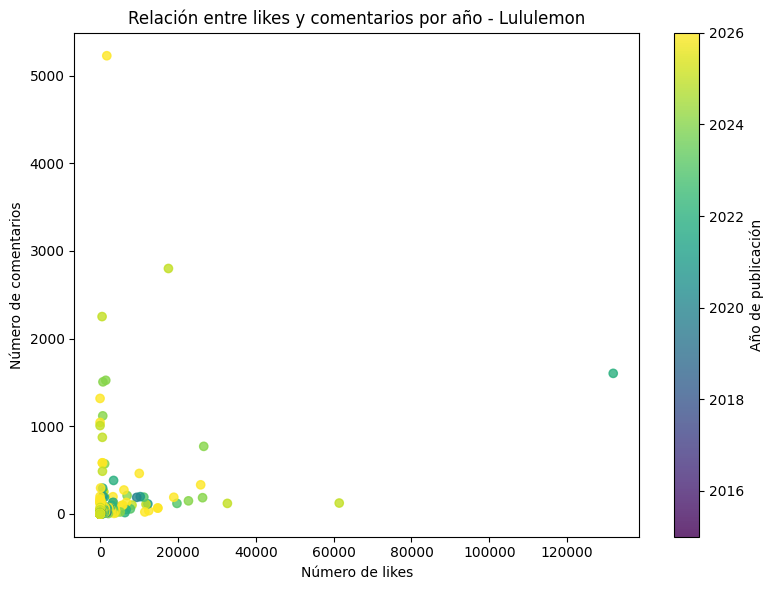

In [18]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_all["likes_std"],
    df_all["comments_std"],
    c=df_all["year"],
    cmap="viridis",
    alpha=0.8
)
plt.xlabel("Número de likes")
plt.ylabel("Número de comentarios")
plt.title("Relación entre likes y comentarios por año - Lululemon")
cbar = plt.colorbar(scatter)
cbar.set_label("Año de publicación")
plt.tight_layout()
plt.show()

---
## 6. Distribución por año

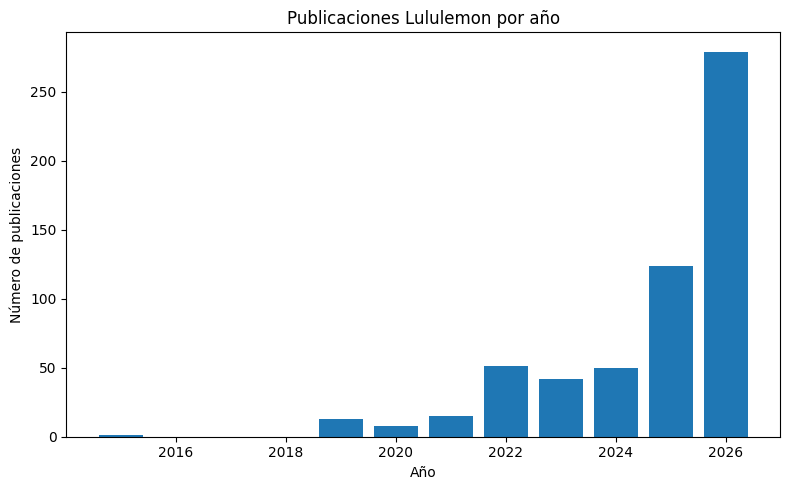

In [19]:
counts_year = df_all.groupby("year").size().reset_index(name="n")

plt.figure(figsize=(8, 5))
plt.bar(counts_year["year"], counts_year["n"])
plt.title("Publicaciones Lululemon por año")
plt.xlabel("Año")
plt.ylabel("Número de publicaciones")
plt.tight_layout()
plt.show()

---
## 7. Engagement combinado (likes, comentarios, año)

/Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/.venv/lib/python3.11/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


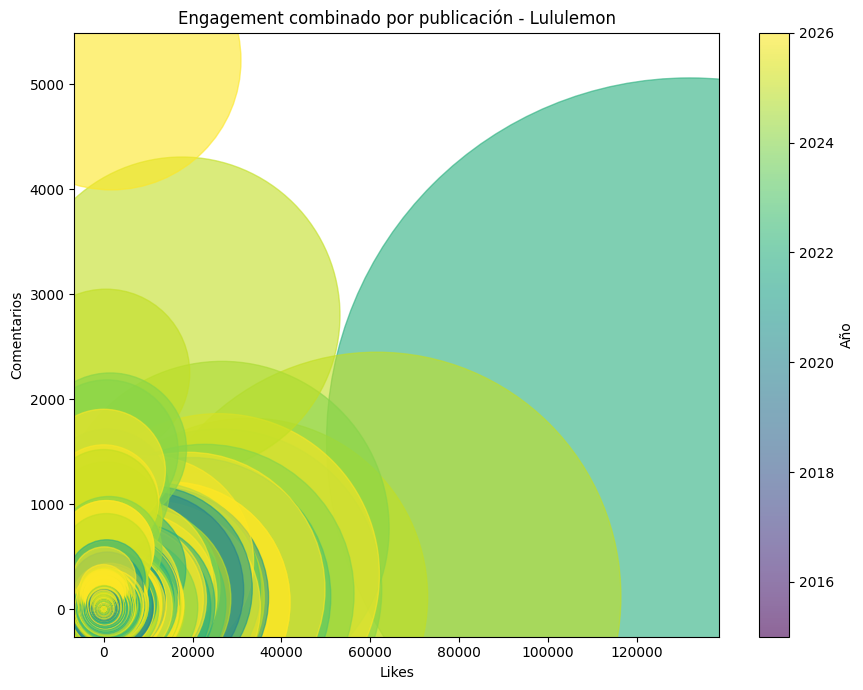

In [20]:
plt.figure(figsize=(9, 7))
sizes = df_all["score"] * 2
scatter = plt.scatter(
    df_all["likes_std"],
    df_all["comments_std"],
    s=sizes,
    c=df_all["year"],
    alpha=0.6
)
plt.xlabel("Likes")
plt.ylabel("Comentarios")
plt.title("Engagement combinado por publicación - Lululemon")
plt.colorbar(scatter, label="Año")
plt.tight_layout()
plt.show()

---
## 8. Selección de publicaciones top para extraer comentarios

Se seleccionan las publicaciones con mayor engagement (likes + comentarios) para luego extraer sus comentarios.

In [21]:
# Top publicaciones por score (likes + comentarios) con al menos algunos comentarios
df_candidates = df_all[df_all["comments_std"] > 5].sort_values("score", ascending=False)

print(f"Publicaciones con >5 comentarios: {len(df_candidates)}")
df_candidates[["label", "kind", "likes_std", "comments_std", "score", "year", "url_std"]].head(20)

Publicaciones con >5 comentarios: 227


,label,kind,likes_std,comments_std,score,year,url_std
0,Reel 1,reel,131818,1603,136627,2022.0,https://www.instagram.com/p/CiSz--iDg2N/
1,Reel 2,reel,61435,123,61804,2025.0,https://www.instagram.com/p/DShEoxLAGJW/
2,Reel 3,reel,32705,119,33062,2025.0,https://www.instagram.com/p/DIE6ruFydgH/
3,Reel 4,reel,26631,770,28941,2024.0,https://www.instagram.com/p/C9TgmWayIWL/
4,Reel 5,reel,26330,184,26882,2024.0,https://www.instagram.com/p/DAl5MSDywMJ/
5,Reel 6,reel,25843,331,26836,2026.0,https://www.instagram.com/p/DTXzbP0DUOu/
6,Reel 7,reel,17561,2800,25961,2025.0,https://www.instagram.com/p/DSobwtFDgpn/
7,Reel 8,reel,22704,148,23148,2024.0,https://www.instagram.com/p/DBWeiONpNdr/
8,Reel 9,reel,19754,119,20111,2023.0,https://www.instagram.com/p/CnonGgBIXCJ/
9,Reel 10,reel,18936,189,19503,2026.0,https://www.instagram.com/p/DVjX22jjxJq/


In [22]:
# Seleccionar top 10 publicaciones para extraer comentarios
N_TOP = 10
df_selected = df_candidates.head(N_TOP).copy()

print(f"Seleccionadas: {len(df_selected)} publicaciones")
df_selected[["label", "kind", "likes_std", "comments_std", "score", "year", "url_std"]]

Seleccionadas: 10 publicaciones


,label,kind,likes_std,comments_std,score,year,url_std
0,Reel 1,reel,131818,1603,136627,2022.0,https://www.instagram.com/p/CiSz--iDg2N/
1,Reel 2,reel,61435,123,61804,2025.0,https://www.instagram.com/p/DShEoxLAGJW/
2,Reel 3,reel,32705,119,33062,2025.0,https://www.instagram.com/p/DIE6ruFydgH/
3,Reel 4,reel,26631,770,28941,2024.0,https://www.instagram.com/p/C9TgmWayIWL/
4,Reel 5,reel,26330,184,26882,2024.0,https://www.instagram.com/p/DAl5MSDywMJ/
5,Reel 6,reel,25843,331,26836,2026.0,https://www.instagram.com/p/DTXzbP0DUOu/
6,Reel 7,reel,17561,2800,25961,2025.0,https://www.instagram.com/p/DSobwtFDgpn/
7,Reel 8,reel,22704,148,23148,2024.0,https://www.instagram.com/p/DBWeiONpNdr/
8,Reel 9,reel,19754,119,20111,2023.0,https://www.instagram.com/p/CnonGgBIXCJ/
9,Reel 10,reel,18936,189,19503,2026.0,https://www.instagram.com/p/DVjX22jjxJq/


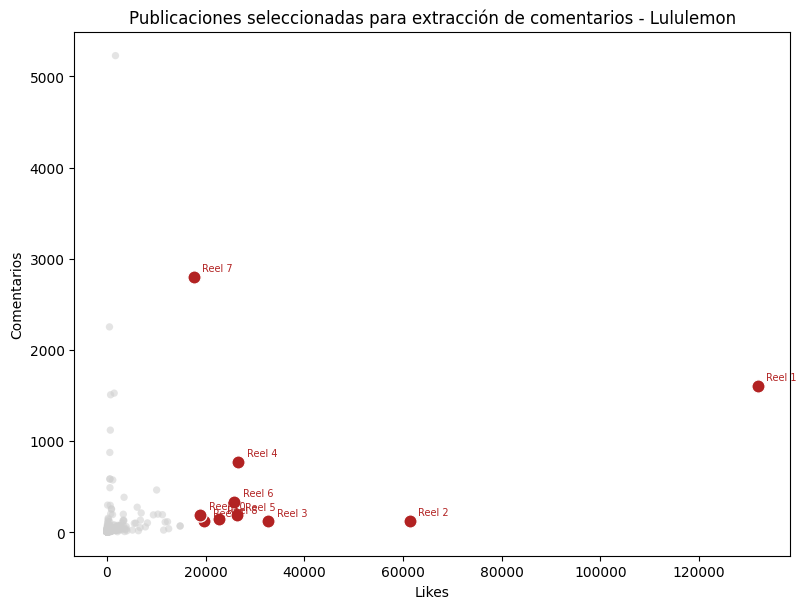

In [23]:
# Visualización: destacar seleccionados
df_plot = df_all[(df_all["likes_std"] > 0) & (df_all["comments_std"] > 0)]

fig, ax = plt.subplots(figsize=(8.2, 6.2))

ax.scatter(
    df_plot["likes_std"], df_plot["comments_std"],
    s=28, color="#cfcfcf", alpha=0.55, edgecolors="none"
)

ax.scatter(
    df_selected["likes_std"], df_selected["comments_std"],
    s=90, color="#b22222", edgecolors="white", linewidths=0.9, zorder=3
)

for _, row in df_selected.iterrows():
    ax.annotate(
        row["label"],
        (row["likes_std"], row["comments_std"]),
        textcoords="offset points", xytext=(6, 4),
        fontsize=7, color="#b22222"
    )

ax.set_xlabel("Likes")
ax.set_ylabel("Comentarios")
ax.set_title("Publicaciones seleccionadas para extracción de comentarios - Lululemon")
plt.tight_layout()
plt.show()

---
## 9. Extracción de comentarios de las publicaciones seleccionadas

Se usa el Actor Apify `SbK00X0JYCPblD2wp` para extraer comentarios de las URLs seleccionadas.

In [24]:
selected_urls = df_selected["url_std"].dropna().unique().tolist()
print(f"URLs para extraer comentarios: {len(selected_urls)}")
for u in selected_urls:
    print(f"  {u}")

URLs para extraer comentarios: 10
  https://www.instagram.com/p/CiSz--iDg2N/
  https://www.instagram.com/p/DShEoxLAGJW/
  https://www.instagram.com/p/DIE6ruFydgH/
  https://www.instagram.com/p/C9TgmWayIWL/
  https://www.instagram.com/p/DAl5MSDywMJ/
  https://www.instagram.com/p/DTXzbP0DUOu/
  https://www.instagram.com/p/DSobwtFDgpn/
  https://www.instagram.com/p/DBWeiONpNdr/
  https://www.instagram.com/p/CnonGgBIXCJ/
  https://www.instagram.com/p/DVjX22jjxJq/


In [25]:
ACTOR_ID = "SbK00X0JYCPblD2wp"

run_comments = client.actor(ACTOR_ID).call(run_input={
    "directUrls": selected_urls,
    "resultsLimit": 2500,
    "includeNestedComments": True,
})

# Recoger resultados
rows = []
for item in client.dataset(run_comments["defaultDatasetId"]).iterate_items():
    if isinstance(item, dict):
        if "comments" in item:
            post_url = item.get("url") or item.get("postUrl") or item.get("post_url") or ""
            for c in item.get("comments") or []:
                if isinstance(c, dict):
                    rows.append({
                        "post_url": post_url,
                        "comment_id": c.get("id"),
                        "text": c.get("text") or c.get("message"),
                        "timestamp": c.get("timestamp") or c.get("created_at"),
                        "likes": c.get("likesCount") or c.get("likes_count") or 0,
                        "username": (c.get("owner") or c.get("user") or {}).get("username", "") if isinstance(c.get("owner") or c.get("user"), dict) else "",
                    })
                elif isinstance(c, str):
                    rows.append({"post_url": post_url, "comment_id": "", "text": c, "timestamp": "", "likes": 0, "username": ""})
        elif item.get("type") == "comment" or "text" in item or "message" in item:
            rows.append({
                "post_url": item.get("postUrl") or item.get("post_url") or "",
                "comment_id": item.get("id"),
                "text": item.get("text") or item.get("message", ""),
                "timestamp": item.get("timestamp") or item.get("created_at"),
                "likes": item.get("likesCount") or item.get("likes_count") or 0,
                "username": (item.get("user") or item.get("owner") or {}).get("username", "") if isinstance(item.get("user") or item.get("owner"), dict) else "",
            })

df_comments = pd.DataFrame(rows)
print(f"Comentarios extraídos: {len(df_comments)}")

# Guardar JSON y CSV
with open("../datos/raw/instagram/ig_lululemon_comentarios_raw.json", "w", encoding="utf-8") as f:
    json.dump(rows, f, ensure_ascii=False, indent=2)

df_comments.to_csv("../datos/raw/instagram/ig_lululemon_comentarios_raw.csv", index=False, encoding="utf-8-sig")
df_comments.head(10)

[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> Status: RUNNING, Message: 
[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> 2026-03-26T15:17:56.300Z ACTOR: Pulling container image of build yv7Xh3xrRXIygu22Q from registry.
[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> 2026-03-26T15:17:56.333Z ACTOR: Creating container.
[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> 2026-03-26T15:17:56.458Z ACTOR: Starting container.
[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> 2026-03-26T15:17:56.459Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> 2026-03-26T15:17:57.242Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.1"}
[apify.instagram-comment-scraper runId:p0LPc6S5zTH4lP0wZ] -> 2026-03-26T15:17:57.391Z INFO  Results Limit [object Object], ACTOR_MAX_PAID_DATASET_ITEMS
[

Comentarios extraídos: 2794


,post_url,comment_id,text,timestamp,likes,username
0,https://www.instagram.com/p/DBWeiONpNdr/,17860467027302927,I promise this reel makes more sense if you wa...,2024-12-18T03:15:21.000Z,777,hiladailythrift
1,https://www.instagram.com/p/DBWeiONpNdr/,18043803248155317,Bought all that for a 5 day gym phase,2025-04-15T17:53:24.000Z,1,lukeplotts
2,https://www.instagram.com/p/DBWeiONpNdr/,18089230600595432,Omg,2025-03-25T02:55:30.000Z,2,blondwiththecuteshoes
3,https://www.instagram.com/p/DBWeiONpNdr/,17847238104430594,All polyester clothes stink,2025-03-17T18:17:01.000Z,1,fourhareathome
4,https://www.instagram.com/p/DBWeiONpNdr/,18059094641011764,Some white girl died today,2025-03-05T23:52:02.000Z,2,thomasscanlon28
5,https://www.instagram.com/p/DBWeiONpNdr/,17980347599804676,"damn I got a bunch at goodwill for $8, 25 is c...",2025-02-23T15:27:22.000Z,2,txri
6,https://www.instagram.com/p/DBWeiONpNdr/,17903472018011646,SMH eww 😂,2025-01-27T03:08:26.000Z,1,annalovey22
7,https://www.instagram.com/p/DBWeiONpNdr/,18058415095942571,Can’t you exchange them for new ones with lulu...,2025-01-23T05:43:05.000Z,8,jonahwegegener26
8,https://www.instagram.com/p/DBWeiONpNdr/,18064009339723750,fun fact! not a single damn piece is washed! i...,2025-01-22T23:05:04.000Z,5,an4lgesic
9,https://www.instagram.com/p/DBWeiONpNdr/,18083208691586722,"As someone who works at a thrift store, we get...",2025-01-21T06:09:47.000Z,2,polopony20


In [26]:
# Resumen por post
if "post_url" in df_comments.columns and len(df_comments) > 0:
    n_urls = df_comments["post_url"].nunique()
    print(f"Posts distintos: {n_urls}")
    print(f"Total comentarios: {len(df_comments)}\n")
    print("Comentarios por post:")
    print(df_comments["post_url"].value_counts().to_frame(name="n_comentarios"))
else:
    print("No hay comentarios o falta la columna post_url")

Posts distintos: 10
Total comentarios: 2794

Comentarios por post:
                                          n_comentarios
post_url                                               
https://www.instagram.com/p/DSobwtFDgpn/           1392
https://www.instagram.com/p/C9TgmWayIWL/            434
https://www.instagram.com/p/DTXzbP0DUOu/            266
https://www.instagram.com/p/DAl5MSDywMJ/            119
https://www.instagram.com/p/DVjX22jjxJq/            116
https://www.instagram.com/p/DIE6ruFydgH/            111
https://www.instagram.com/p/DShEoxLAGJW/            103
https://www.instagram.com/p/DBWeiONpNdr/             99
https://www.instagram.com/p/CnonGgBIXCJ/             82
https://www.instagram.com/p/CiSz--iDg2N/             72


---
## 10. Filtrado de comentarios por idioma (zona geográfica)

Misma lógica que TikTok: se filtran comentarios por idioma como proxy de zona geográfica.
- **US**: inglés (`en`)
- **Europa**: español (`es`), francés (`fr`), inglés (`en`), alemán (`de`), neerlandés (`nl`), rumano (`ro`), italiano (`it`), finés (`fi`), unknown


In [5]:
import pandas as pd
from langdetect import detect, LangDetectException

def safe_detect(text):
    """Detecta idioma de un texto de forma segura."""
    try:
        if pd.isna(text) or str(text).strip() == "":
            return "unknown"
        return detect(str(text))
    except LangDetectException:
        return "unknown"

# Cargar comentarios desde raw (sin necesidad de llamar a la API)
df_comments = pd.read_csv("../datos/raw/instagram/ig_lululemon_comentarios_raw.csv")
print(f"Comentarios cargados desde raw: {len(df_comments)}")

# Detectar idioma de cada comentario
df_comments["lang"] = df_comments["text"].apply(safe_detect)

print("\nDistribución de idiomas detectados:")
print(df_comments["lang"].value_counts().head(15))

Comentarios cargados desde raw: 2794

Distribución de idiomas detectados:
lang
en         1147
unknown     550
lt          211
sq          123
de           90
sl           86
et           52
nl           50
ro           43
af           38
cy           37
it           36
tl           34
fi           30
id           29
Name: count, dtype: int64


In [6]:
# Filtrar por zona geográfica
LANG_US = ["en"]
LANG_EUROPE = ["es", "fr", "de", "nl", "ro", "it", "fi"]

df_us = df_comments[df_comments["lang"].isin(LANG_US)].copy()
df_us["region"] = "US"

df_europe = df_comments[df_comments["lang"].isin(LANG_EUROPE)].copy()
df_europe["region"] = df_europe["lang"].map({
    "es": "ES",
    "fr": "FR",
    "de": "DE",
    "nl": "NL",
    "ro": "RO",
    "it": "IT",
    "fi": "FI",
})

print(f"Comentarios US (inglés): {len(df_us)}")
print(f"Comentarios Europa: {len(df_europe)}")
print(f"\nDesglose Europa:")
print(df_europe["region"].value_counts())

Comentarios US (inglés): 1147
Comentarios Europa: 291

Desglose Europa:
region
DE    90
NL    50
RO    43
IT    36
FI    30
FR    29
ES    13
Name: count, dtype: int64


In [7]:
# Guardar comentarios filtrados por región
df_us.to_csv("../datos/processed/instagram/ig_lululemon_comentarios_US.csv", index=False, encoding="utf-8-sig")
df_europe.to_csv("../datos/processed/instagram/ig_lululemon_comentarios_EUROPE.csv", index=False, encoding="utf-8-sig")

print("Guardados:")
print(f"  ../datos/processed/instagram/ig_lululemon_comentarios_US.csv     ({len(df_us)} comentarios)")
print(f"  ../datos/processed/instagram/ig_lululemon_comentarios_EUROPE.csv ({len(df_europe)} comentarios)")

Guardados:
  ../datos/processed/instagram/ig_lululemon_comentarios_US.csv     (1147 comentarios)
  ../datos/processed/instagram/ig_lululemon_comentarios_EUROPE.csv (291 comentarios)


In [8]:
# Guardar también los datos de publicaciones para referencia
df_all.to_csv("../datos/processed/instagram/ig_lululemon_publicaciones.csv", index=False, encoding="utf-8-sig")
print(f"Publicaciones guardadas: ../datos/processed/instagram/ig_lululemon_publicaciones.csv ({len(df_all)} filas)")

NameError: name 'df_all' is not defined